In [45]:
#importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from adjustText import adjust_text


#loading data 
dataset=load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()


#Data Cleanup
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#Filter for Data Analyst role
df_DA= df[df['job_title_short'] == 'Data Analyst'].copy()

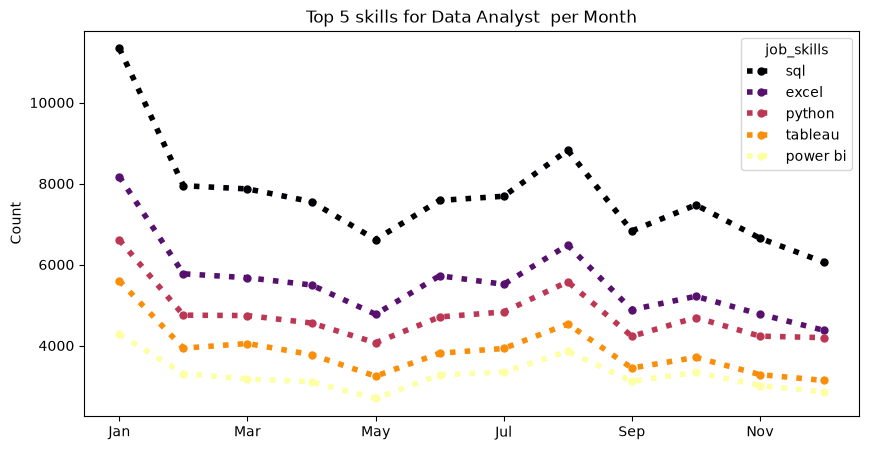

In [25]:
#create a new column for month number 
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month
#Explode the job skills column and pivot
df_DA_explode = df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no',columns='job_skills', aggfunc='size', fill_value=0)
# sort the skills by count
df_DA_pivot.loc['Total']= df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

df_DA_pivot

#use month names for plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month']= df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime( "%b"))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

#get the top 5 skills 
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':',
    colormap='inferno', # inferno , plasma , magma , cividis
    marker= 'o',
    markersize=5,
    figsize=(10,5)
    )
plt.title('Top 5 skills for Data Analyst  per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [61]:
# Scatter plot

df_DA_exploded = df_DA.explode('job_skills')
skill_stats = df_DA_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary = ('salary_year_avg','median')
)

#limit to top 20 skills
skills_count= 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skills_count)

skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.000000
excel,66860,84479.000000
python,57190,98500.000000
tableau,46455,95000.000000
power bi,39380,90000.000000
r,29996,92527.500000
sas,27998,90000.000000
powerpoint,13822,85000.000000
word,13562,80000.000000


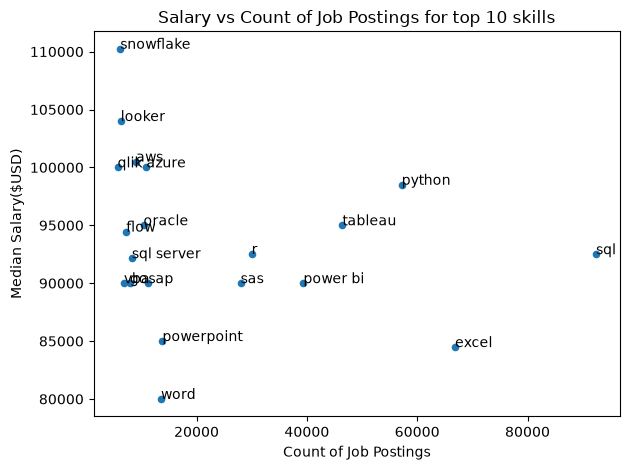

In [62]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary($USD)')
plt.title('Salary vs Count of Job Postings for top 10 skills')
plt.tight_layout()
for i, txt in enumerate(skill_stats.index): #for adding titles to scatter plot points
   plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)
plt.show()

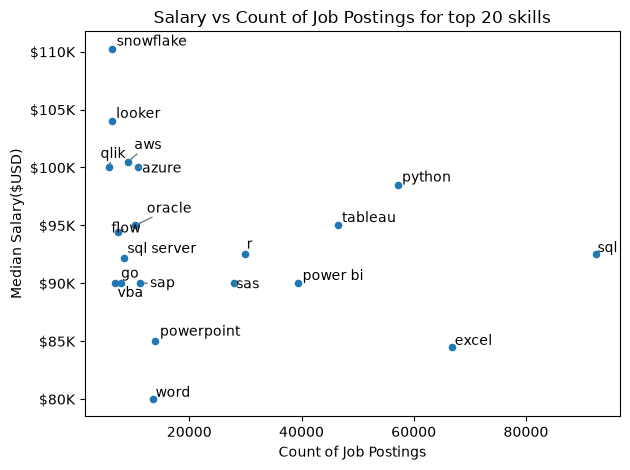

In [64]:
#fig , ax = plt.subplots()

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
#create empty list
texts=[]

for i, txt in enumerate(skill_stats.index):                   #for adding titles to scatter plot points
  texts.append(
    plt.text(
      skill_stats['skill_count'].iloc[i],
      skill_stats['median_salary'].iloc[i],
      txt
      )
    )


#adjust all text
adjust_text(
  texts,
    #force_text=(1.5, 2),
    #force_points=(0.5, 1),
    #expand_text=(1.5, 1.5),
    #expand_points=(1.5, 1.5),
    arrowprops=dict(
        arrowstyle="->",
        color='gray',
        lw=1
    )
    )

ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos : f'${int(y/1000)}K'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Salary($USD)')
plt.title(f'Salary vs Count of Job Postings for top {skills_count} skills')
plt.tight_layout() 
plt.show()